# CSV_file_Blood_Binary_Classification_Keras

### Keras 모델을 이용하여, 나이(BTH_G)와 체질량지수(BMI)로 고혈압 진단 여부(DIS)를 예측하는 Binary Classification을 구현하라
### (Colab을 사용하는 경우 "files/blood.csv"를 "내 드라이브/files/"에 복사)

>### Load modules

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd

print("NumPy Version :{}".format(np.__version__))
print("TensorFlow Version :{}".format(tf.__version__))
print("Matplotlib Version :{}".format(plt.matplotlib.__version__))
print("Pandas Version :{}".format(pd.__version__))

NumPy Version :1.26.4
TensorFlow Version :2.18.0
Matplotlib Version :3.10.0
Pandas Version :2.2.2


In [2]:
colab=True
try:
  from google.colab import drive
except:
  colab =False
if colab :
    drive.mount('/content/drive')
    print('g-drive mounted.')
else : print('local drive.')

Mounted at /content/drive
g-drive mounted.


In [3]:
# file path: 다른 경로에 실습파일을 복사했다면, 아래 경로를 수정하세요

if colab :
  files_path = '/content/drive/MyDrive/[SOL]LAB_05_CSV_file_Blood_Binary_Classification_Keras/files/blood.csv'
else :
  files_path = '../files/blood.csv'

In [4]:
# LinearRegression.csv 파일 읽기
# pd.set_option('display.max_rows', None) ## 모든 행을 출력한다.
df = pd.read_csv(files_path)
df.head()

,SEX,BTH_G,SBP,DBP,FBS,DIS,BMI
0,1,1,116,78,94,4,16.6
1,1,1,100,60,79,4,22.3
2,1,1,100,60,87,4,21.9
3,1,1,111,70,72,4,20.2
4,1,1,120,80,98,4,20.0


In [5]:
idx = df[df['SEX']==2].index
df = df.drop(idx)
df['DIS'].replace([1,2,3,4],[1,1,0,0], inplace=True )

df.sort_values(by=['DIS','BTH_G'], inplace=True)

<ipython-input-5-f5d341751946>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['DIS'].replace([1,2,3,4],[1,1,0,0], inplace=True )


In [6]:
input = np.array(df[['BTH_G', 'BMI']], dtype= np.float32)
target = np.array(df['DIS'], dtype= np.float32).reshape((-1,1))
input, target

(array([[ 1. , 16.6],
        [ 1. , 22.3],
        [ 1. , 21.9],
        ...,
        [27. , 20.7],
        [27. , 24.6],
        [27. , 23. ]], dtype=float32),
 array([[0.],
        [0.],
        [0.],
        ...,
        [1.],
        [1.],
        [1.]], dtype=float32))

In [7]:
dis = df['DIS']
print(dis.value_counts())
dis.value_counts()[0]

DIS
0    402356
1    107871
Name: count, dtype: int64


402356

In [8]:
# BAL: 0, 1 label 개수가 균형 => True
BAL = True
if BAL == False:
  x_input = input[::5000]
  labels = target[::5000]
else:
  x_input = np.zeros((200,2),dtype=np.float32)
  labels = np.zeros((200,1),dtype=np.float32)

  x_input[:100] = input[:400000:4000]
  x_input[100:200] = input[410000:510000:1000]

  labels[:100] = target[:400000:4000]
  labels[100:200] = target[410000:510000:1000]

In [9]:
x_input.shape, labels.shape

((200, 2), (200, 1))

In [10]:
# 1. Min Max Scaler 적용


In [11]:
# 2. Keras Model 정의, Model compile, Model summary


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 1)                   │               3 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
# 3. Model Fit

In [13]:
%%time


스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
Epoch 2502/5000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7426 - loss: 0.5191 
Epoch 2503/5000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7934 - loss: 0.4646 
Epoch 2504/5000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7831 - loss: 0.4764 
Epoch 2505/5000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7591 - loss: 0.4870 
Epoch 2506/5000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7512 - loss: 0.5111 
Epoch 2507/5000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7583 - loss: 0.4840 
Epoch 2508/5000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7904 - loss: 0.4620 
Epoch 2509/5000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7789 - loss: 0.4626 
Epoch 2510/5000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7744 - loss: 0.4818 
Epoch 2511/5000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7529 - loss: 0.4799 
Epoch 2512/5000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7404 - loss: 0.49

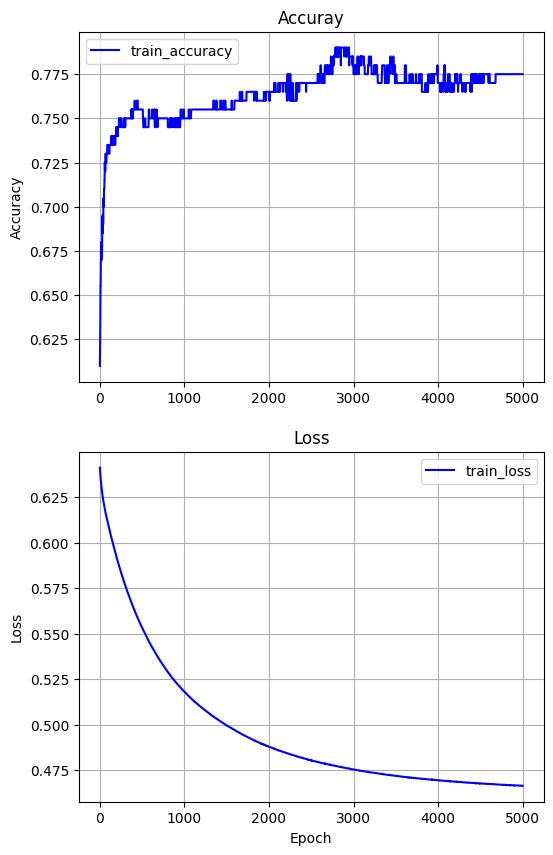

In [14]:
# 4. accuray, loss 그래프 출력


In [15]:
# 5. parameter(W,B) 출력


[array([[6.191077 ],
       [2.6267884]], dtype=float32), array([-4.654537], dtype=float32)]


In [16]:
# 6. Predict (x_input 사용)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
x:[0. 0.], h:[0.00942857], l:[0.]
x:[0.         0.46276587], h:[0.03110014], l:[0.]
x:[0.         0.51595736], h:[0.03559774], l:[0.]
x:[0.03846154 0.7978723 ], h:[0.08943304], l:[0.]
x:[0.03846154 0.12765954], h:[0.01660864], l:[0.]
x:[0.03846154 0.49999994], h:[0.04298266], l:[0.]
x:[0.07692308 0.287234  ], h:[0.03155995], l:[0.]
x:[0.07692308 0.87765944], h:[0.13320942], l:[0.]
x:[0.07692308 0.2712766 ], h:[0.03030367], l:[0.]
x:[0.07692308 0.22340418], h:[0.02681886], l:[0.]
x:[0.11538462 0.574468  ], h:[0.08082604], l:[0.]
x:[0.11538462 0.41489354], h:[0.05466351], l:[0.]
x:[0.11538462 0.2712766 ], h:[0.03814035], l:[0.]
x:[0.11538462 0.5585106 ], h:[0.07776612], l:[0.]
x:[0.15384616 0.8138297 ], h:[0.17302974], l:[0.]
x:[0.15384616 0.23404253], h:[0.04363485], l:[0.]
x:[0.15384616 0.643617  ], h:[0.1180093], l:[0.]
x:[0.15384616 0.3563829 ], h:[0.05919376], l:[0.]
x:[0.15384616 0.3351063 ], h:[0.05615691], l:[0.]
x:[0.15384616 1.        ], h:

In [17]:
# 7. predict (BTH_G는 20, BMI는 30일 때 DIS를 예측)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step

[ Prediction by specific data ]
BTH_G : 20.0, BMI : 30.0 = > DIS :  0.8509
